
Zeitzeugeninterviews Mauerfall 1989 - Analyse
BERTopic Topic Modelling + Manuelle Emotionsannotation (ELAN)

Analyse von 20 Zeitzeugeninterviews (PDFs) in zwei Gruppen: vor_Mauerfall - 10 Interviews aus der Zeit der Oktoberproteste 1989 + nach_Mauerfall - 10 Interviews aus der Zeit nach dem 9. November 1989

METHODE:
Topic Modelling → BERTopic (satzbasierte Segmentierung, Seeded Topics)
Emotionsanalyse → Manuelle Annotation mit ELAN (Plutchiks Rad der Emotionen, 10 Kategorien)

WARUM SATZEBENE?
Jedes PDF (~1–1,5 Seiten) wird vor dem Embedding in einzelne Sätze
segmentiert. So entstehen aus 20 kurzen Dokumenten ca. 700 analysierbare Einheiten, was ausreichend für stabile BERTopic-Cluster ist. Jeder Satz bleibt mit seinem Quelldokument und seiner Gruppe verknüpft, sodass Auswertungen auf Dokument- und Gruppenebene vollständig erhalten bleiben.

WARUM SEEDED TOPICS?
Ein erster unüberwachter Durchlauf produzierte 66 instabile Kleinstthemen.
Durch thematische Ankerwörter (Seeds) aus einer Vorlektüre der Transkripte
wurde das Modell auf 5 interpretierbare Themenbereiche gelenkt.

EMOTIONSANNOTATION:
Die ELAN-Annotationen (Tab-delimited Export) werden über Zeitstempel mit den BERTopic-Ergebnissen zusammengeführt. Jedes Emotionssegment erhält das thematisch am stärksten überlappende BERTopic-Thema zugewiesen.


In [51]:
import os
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter, defaultdict

In [52]:

import nltk
import pdfplumber
from nltk.tokenize import sent_tokenize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nrclex import NRCLex
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

In [53]:
import os
from pathlib import Path

print("Working directory:", os.getcwd())

for folder in ["nach_Mauerfall", "vor_Mauerfall"]:
    print(f"\n{folder}:")
    for fp in sorted(Path(folder).glob("*.pdf")):
        print(f"  {fp.name}")


occupation_groups = {
    
    "Andreas Rudolph":    "Staatsnah",   # Militär
    "Günther Schabowski": "Staatsnah",   # SED
    "Toralf Dörre":       "Staatsnah",   # Polizist

   
    "Vera Langsfeld":       "Zivilgesellschaft",  # Bürgerrechtlerin
    "Elke Urban":           "Zivilgesellschaft",  # Aktivistin
    "Eduard Fiedler":       "Zivilgesellschaft",  # Kirche
    "Siegbert Schefke":     "Zivilgesellschaft",  # Journalist/Opposition

    
    "Jana Hensel":      "Medien & Intellektuelle",  # Journalistin 
    "Michael Lersow":   "Medien & Intellektuelle",  # Dozent
    "Franz Müntefering":"Medien & Intellektuelle",  # Westpolitiker

  
    "Gudrun Treichel":      "DDR Bürger",
    "Kerstin Beyer":        "DDR Bürger",
    "Kirsten Külker":       "DDR Bürger",   
    "Jeanne Wirkner":       "DDR Bürger",   
    "Annegret Schowalters": "DDR Bürger",
    "Heidrun Smers":        "DDR Bürger",
    "Jörg Philipp":         "DDR Bürger",
    "Stephan Werner":       "DDR Bürger",
    "Thomas Heil":          "DDR Bürger",
}

Working directory: c:\Users\theod\Desktop\Project\Interviews

nach_Mauerfall:
  Andreas Rudolph.pdf
  Eduard Fiedler.pdf
  Franz Müntefering.pdf
  Gudrun Treichel.pdf
  Jana Hensel.pdf
  Jeanne Wirkner.pdf
  Kerstin Beyer.pdf
  Kirsten Külker.pdf
  Michael Lersow.pdf
  Vera Langsfeld.pdf

vor_Mauerfall:
  Annegret Schowalters.pdf
  Elke Urban.pdf
  Günther Schabowski.pdf
  Heidrun Smers.pdf
  Jana Hensel.pdf
  Jörg Philipp.pdf
  Siegbert Schefke.pdf
  Stephan Werner.pdf
  Thomas Heil.pdf
  Toralf Dörre.pdf


In [54]:
def load_pdf(path):
    text = ""
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages:
            t = page.extract_text()
            if t: text += t + "\n"
    return text.strip()

all_sentences   = []
all_files       = []
all_periods     = []
all_occupations = []


for folder, period_label in [("nach_Mauerfall", "after"), ("vor_Mauerfall", "before")]:
    for fp in sorted(Path(folder).glob("*.pdf")):
        stem = fp.stem
        occupation = occupation_groups.get(stem, "Unbekannt")
        period_label_final = period_label

        text  = load_pdf(fp)
        sents = [s.strip() for s in sent_tokenize(text) if len(s.split()) >= 5]

        all_sentences.extend(sents)
        all_files.extend([f"{stem} ({period_label})"] * len(sents))
        all_periods.extend([period_label_final] * len(sents))
        all_occupations.extend([occupation] * len(sents))

print(f"Total sentences: {len(all_sentences)}")
print(f"Files loaded:    {len(set(all_files))}")




Total sentences: 705
Files loaded:    20


In [55]:
import spacy
from sklearn.feature_extraction.text import CountVectorizer

nlp = spacy.load("de_core_news_sm")
spacy_stopwords = list(nlp.Defaults.stop_words)

custom_stopwords = [
    "gut", "nächsten", "hand", "sofort", "montag", "niemand", "groß", "große",
    "großes", "würde", "würden", "aktuelle", "aktuell", "gleich", "zwei",
    "genug", "sonst", "halbes", "sicherlich", "völlig", "neue", "neues",
    "passiert", "schritte", "weiteren", "neu", "gesagt", "sagen", "sagte",
    "gehen", "ging", "kommen", "kam", "machen", "geben", "sehen", "wissen",
    "denken", "glauben", "stehen", "bleiben", "heißen", "nehmen", "erinnern",
    "heute", "morgen", "gestern", "tag", "nacht", "jahr", "jahre", "jahren",
    "zeit", "mal", "einmal", "wirklich", "einfach", "vielleicht", "natürlich",
    "überhaupt", "irgendwie", "plötzlich", "eigentlich", "nämlich",
    "allerdings", "außerdem", "jedoch", "dennoch", "trotzdem", "schließlich",
    "damals", "daher", "davon", "dazu", "dabei", "damit", "daran", "darauf",
]

all_stopwords = list(set(spacy_stopwords + custom_stopwords))

vectorizer = CountVectorizer(
    min_df=2,
    ngram_range=(1, 1),
    stop_words=all_stopwords,
)

In [69]:
from bertopic.representation import KeyBERTInspired
from sklearn.feature_extraction.text import CountVectorizer

embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

seed_topic_list = [
    ["mauer", "mauerfall", "grenze", "übergang", "bornholmer", "westberlin"],
    ["demonstration", "demonstranten", "montagsdemo", "protest", "leipzig", "straße"],
    ["angst", "gefahr", "gewalt", "polizei", "kampfgruppen", "waffe"],
    ["freiheit", "hoffnung", "freude", "gefühl", "tränen", "glücklich"],
    ["ddr", "sed", "staat", "system", "sozialismus", "regime"],
    ["kirche", "nikolaikirche", "glaube", "gemeinschaft", "gebet"],
    ["einheit", "bundesrepublik", "westen", "deutschland", "zukunft"],
    ["familie", "kinder", "zuhause", "alltag", "leben"],
]

topic_model = BERTopic(
    embedding_model=embedding_model,
    min_topic_size=12,
    nr_topics=7,
    vectorizer_model=vectorizer,
    seed_topic_list=seed_topic_list,
    verbose=True,
)
topics, probs = topic_model.fit_transform(all_sentences)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2855.43it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-18 16:53:02,684 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 23/23 [00:05<00:00,  3.92it/s]
2026-03-18 16:53:08,582 - BERTopic - Embedding - Completed ✓
2026-03-18 16:53:08,584 - BERTopic - Guided - Find embeddings highly related to seeded topics.
Batches: 100%|██████████| 1/1 [00:00<00:00, 16.78it/s]
2026-03-18 16:53:08,664 - BERTopic - Guided - Completed ✓
2026-03-18 16:53:08,664 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-18 16:53:09,887 - BERTopic - Dimensionality - Completed ✓
2026-03-18 16

In [70]:
def topic_label(tid):
    words = topic_model.get_topic(tid)
    if not words: return "Outlier"
    return f"T{tid}: " + " | ".join([w for w, _ in words[:4]])

results_df = pd.DataFrame({
    "sentence":   all_sentences,
    "file":       all_files,
    "period":     all_periods,
    "occupation": all_occupations,
    "topic":      topics,
})
results_df["topic_label"] = results_df["topic"].apply(topic_label)


In [71]:
print("TOPICS")
for t in topic_model.get_topic_info().itertuples():
    if t.Topic == -1:
        print(f"  Outliers: {t.Count} sentences")
        continue
    words = " | ".join([w for w, _ in topic_model.get_topic(t.Topic)[:6]])
    print(f"  Topic {t.Topic:2d} ({t.Count:3d} sentences): {words}")

TOPICS
  Outliers: 263 sentences
  Topic  0 (152 sentences): mauer | november | mauerfall | fall | glaube | leben
  Topic  1 ( 80 sentences): leipzig | ddr | kirche | nikolaikirche | 1989 | november
  Topic  2 ( 78 sentences): wusste | weiß | verstanden | klar | gesehen | miteinander
  Topic  3 ( 55 sentences): ddr | bundesrepublik | land | sed | hensel | staat
  Topic  4 ( 48 sentences): standen | kampfgruppen | gewalt | menschenmassen | gefahr | leben
  Topic  5 ( 29 sentences): demonstration | demonstrationen | demonstranten | leipziger | 1989 | menschen


In [72]:
topic_names = {
    0:  "Mauerfall & persönliches Erleben",
    1:  "Leipzig & Kirche",
    3:  "DDR-System & Politik",
    4:  "Gewalt & Sicherheitskräfte",
    5:  "Demonstrationen & Protest",
    -1: "Outlier",
}

results_df["topic_label"] = results_df["topic"].apply(
    lambda tid: topic_names.get(tid, "Outlier")  
)

In [73]:
summary = (results_df[results_df["topic_label"] != "Outlier"]
           .groupby(["topic_label", "period"])
           .size()
           .unstack(fill_value=0)
           .assign(Total=lambda x: x.sum(axis=1))
           .sort_values("Total", ascending=False))

print(summary.to_string())

period                            after  before  Total
topic_label                                           
Mauerfall & persönliches Erleben     83      69    152
Leipzig & Kirche                     36      44     80
DDR-System & Politik                 32      23     55
Gewalt & Sicherheitskräfte           10      38     48
Demonstrationen & Protest             1      28     29


In [74]:
print("NACH ZEIT")
period_cross = results_df[results_df["topic"] != -1].groupby(
    ["period", "topic_label"]).size().unstack(fill_value=0)
print(period_cross.to_string())

NACH ZEIT
topic_label  DDR-System & Politik  Demonstrationen & Protest  Gewalt & Sicherheitskräfte  Leipzig & Kirche  Mauerfall & persönliches Erleben  Outlier
period                                                                                                                                               
after                          32                          1                          10                36                                83       35
before                         23                         28                          38                44                                69       43


In [75]:
print("NACH BERUFSGRUPPE")
occ_cross = results_df[results_df["topic"] != -1].groupby(
    ["occupation", "topic_label"]).size().unstack(fill_value=0)
print(occ_cross.to_string())

NACH BERUFSGRUPPE
topic_label              DDR-System & Politik  Demonstrationen & Protest  Gewalt & Sicherheitskräfte  Leipzig & Kirche  Mauerfall & persönliches Erleben  Outlier
occupation                                                                                                                                                       
DDR Bürger                                  7                         10                          24                38                                77       41
Medien & Intellektuelle                    27                          7                           6                14                                30       16
Staatsnah                                   6                          7                          10                 4                                 8       11
Zivilgesellschaft                          15                          5                           8                24                                37       10


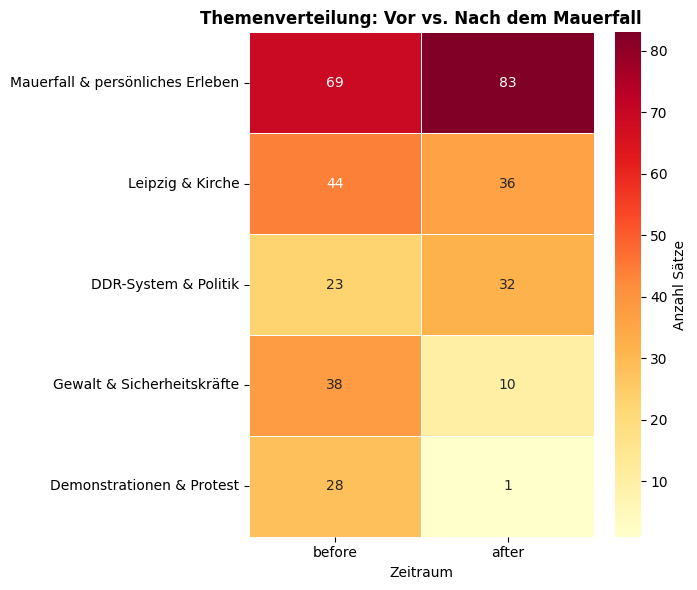

Saved: topic_period_heatmap.png


In [76]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

Path("output/figures").mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(summary[["before", "after"]], annot=True, fmt="d",
            cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Anzahl Sätze"})
ax.set_title("Themenverteilung: Vor vs. Nach dem Mauerfall",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Zeitraum")
ax.set_ylabel("")
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("output/figures/topic_period_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: topic_period_heatmap.png")

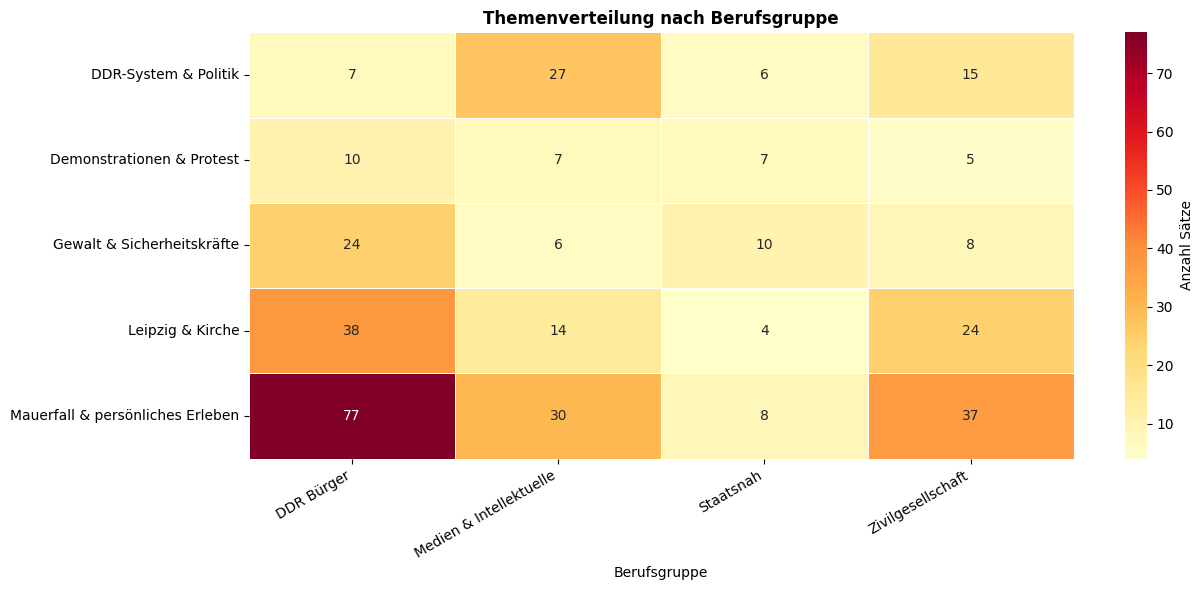

Saved: topic_occupation_heatmap.png


In [77]:
occ_summary = (results_df[results_df["topic_label"] != "Outlier"]
               .groupby(["topic_label", "occupation"])
               .size()
               .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(occ_summary, annot=True, fmt="d",
            cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Anzahl Sätze"})
ax.set_title("Themenverteilung nach Berufsgruppe",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Berufsgruppe")
ax.set_ylabel("")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("output/figures/topic_occupation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: topic_occupation_heatmap.png")

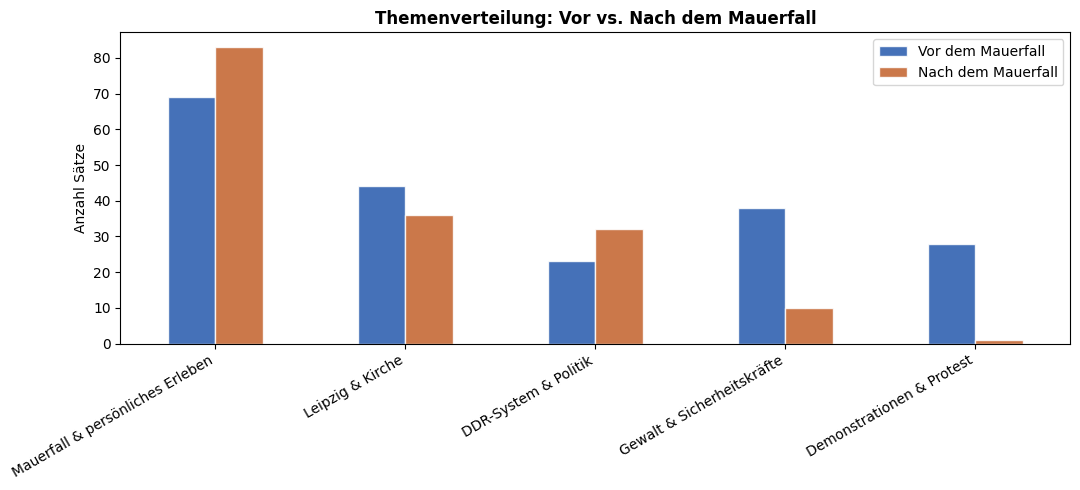

Saved: topic_period_barchart.png


In [78]:
colors = ["#2458AC", "#C2612A"]
summary[["before", "after"]].plot(
    kind="bar", figsize=(11, 5),
    color=colors, alpha=0.85, edgecolor="white"
)
plt.title("Themenverteilung: Vor vs. Nach dem Mauerfall",
          fontsize=12, fontweight="bold")
plt.xlabel("")
plt.ylabel("Anzahl Sätze")
plt.xticks(rotation=30, ha="right")
plt.legend(["Vor dem Mauerfall", "Nach dem Mauerfall"])
plt.tight_layout()
plt.savefig("output/figures/topic_period_barchart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: topic_period_barchart.png")

In [79]:
import os
elan_files = os.listdir("elan_exports")
print(sorted(elan_files))

['Andreas Rudolph.txt', 'Annegret Schowalters.txt', 'Eduard Fiedler.txt', 'Elke Urban.txt', 'Franz Müntefering.txt', 'Gudrun Treichel.txt', 'Günther Schabowski.txt', 'Heidrun Smers.txt', 'Jana Hensel(nach).txt', 'Jana Hensel(vor).txt', 'Jeanne Wirkner.txt', 'Jörg Philipp.txt', 'Kerstin Beyer.txt', 'Kirsten Külker.txt', 'Michael Lersow.txt', 'Siegbert Schefke.txt', 'Stephan Werner.txt', 'Thomas Heil.txt', 'Toralf Dörre.txt', 'Vera Langsfeld.txt']


In [80]:
import pandas as pd

def parse_elan_txt(filepath, person_name, period, occupation):
    rows = []
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 5:
                continue
            tier = parts[0].strip()
            begin = parts[2].strip()
            end = parts[3].strip()
            value = parts[4].strip().lower() if len(parts) > 4 else ""
            if tier.lower() in ['emotion', 'thema']:
                rows.append({
                    'person': person_name,
                    'period': period,
                    'occupation': occupation,
                    'tier': tier.lower(),
                    'begin_ms': float(parts[1]),
                    'end_ms': float(parts[3]) if tier.lower() == 'emotion' else None,
                    'begin': begin,
                    'end': end,
                    'value': value
                })
    return rows

ELAN_META = {
    "Andreas Rudolph":      {"period": "after",  "occupation": "Staatsnah"},
    "Annegret Schowalters": {"period": "before", "occupation": "DDR Bürger"},
    "Eduard Fiedler":       {"period": "after",  "occupation": "Zivilgesellschaft"},
    "Elke Urban":           {"period": "before", "occupation": "Zivilgesellschaft"},
    "Franz Müntefering":    {"period": "after",  "occupation": "Medien & Intellektuelle"},
    "Gudrun Treichel":      {"period": "after",  "occupation": "DDR Bürger"},
    "Günther Schabowski":   {"period": "before", "occupation": "Staatsnah"},
    "Heidrun Smers":        {"period": "before", "occupation": "DDR Bürger"},
    "Jana Hensel(vor)":     {"period": "before", "occupation": "Medien & Intellektuelle"},
    "Jana Hensel(nach)":    {"period": "after",  "occupation": "Medien & Intellektuelle"},
    "Jeanne Wirkner":       {"period": "after",  "occupation": "DDR Bürger"},
    "Jörg Philipp":         {"period": "before", "occupation": "DDR Bürger"},
    "Kerstin Beyer":        {"period": "after",  "occupation": "DDR Bürger"},
    "Kirsten Külker":       {"period": "after",  "occupation": "DDR Bürger"},
    "Michael Lersow":       {"period": "after",  "occupation": "Medien & Intellektuelle"},
    "Siegbert Schefke":     {"period": "before", "occupation": "Zivilgesellschaft"},
    "Stephan Werner":       {"period": "before", "occupation": "DDR Bürger"},
    "Thomas Heil":          {"period": "before", "occupation": "DDR Bürger"},
    "Toralf Dörre":         {"period": "before", "occupation": "Staatsnah"},
    "Vera Langsfeld":       {"period": "after",  "occupation": "Zivilgesellschaft"},
}

In [81]:
def parse_elan_txt(filepath, person_name, period, occupation):
    rows = []
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 9:
                continue
            tier  = parts[0].strip()
            begin_ms = parts[3].strip()
            end_ms   = parts[5].strip()
            value    = parts[8].strip().lower()
            if tier.lower() in ['emotion', 'thema'] and begin_ms:
                try:
                    rows.append({
                        'person':     person_name,
                        'period':     period,
                        'occupation': occupation,
                        'tier':       tier.lower(),
                        'begin_ms':   float(begin_ms),
                        'end_ms':     float(end_ms),
                        'value':      value
                    })
                except ValueError:
                    continue
    return rows

In [82]:
all_rows = []
for filename in os.listdir("elan_exports"):
    if not filename.endswith(".txt"):
        continue
    stem = filename.replace(".txt", "")
    meta = ELAN_META[stem]
    rows = parse_elan_txt(
        f"elan_exports/{filename}",
        stem, meta["period"], meta["occupation"]
    )
    all_rows.extend(rows)

elan_df = pd.DataFrame(all_rows)
print(elan_df['tier'].value_counts())
print(elan_df.shape)
elan_df.head(10)

tier
emotion    133
thema      133
Name: count, dtype: int64
(266, 7)


,person,period,occupation,tier,begin_ms,end_ms,value
0,Andreas Rudolph,after,Staatsnah,emotion,0.244,14.530,nachdenklichkeit
1,Andreas Rudolph,after,Staatsnah,emotion,18.020,63.857,besorgnis
2,Andreas Rudolph,after,Staatsnah,emotion,64.419,81.000,neutral
3,Andreas Rudolph,after,Staatsnah,emotion,91.429,121.429,neutral
4,Andreas Rudolph,after,Staatsnah,emotion,133.476,191.429,überraschung
5,Andreas Rudolph,after,Staatsnah,emotion,191.476,212.048,neutral
6,Andreas Rudolph,after,Staatsnah,emotion,212.048,224.667,nachdenklichkeit
7,Andreas Rudolph,after,Staatsnah,thema,0.204,14.531,mauerfall & persönliches erleben
8,Andreas Rudolph,after,Staatsnah,thema,18.000,63.857,mauerfall & persönliches erleben
9,Andreas Rudolph,after,Staatsnah,thema,64.419,81.000,demonstrationen & protest


In [83]:
emotion_df = elan_df[elan_df['tier'] == 'emotion'].copy()
thema_df   = elan_df[elan_df['tier'] == 'thema'].copy()

def find_thema(row, thema_df):
    overlapping = thema_df[
        (thema_df['person'] == row['person']) &
        (thema_df['begin_ms'] < row['end_ms']) &
        (thema_df['end_ms'] > row['begin_ms'])
    ]
    if len(overlapping) == 0:
        return 'kein_thema'
    # Nimm das Thema mit der größten Überlappung
    overlapping = overlapping.copy()
    overlapping['overlap'] = overlapping.apply(
        lambda t: min(t['end_ms'], row['end_ms']) - max(t['begin_ms'], row['begin_ms']),
        axis=1
    )
    return overlapping.loc[overlapping['overlap'].idxmax(), 'value']

emotion_df['thema'] = emotion_df.apply(lambda row: find_thema(row, thema_df), axis=1)

print(emotion_df['value'].value_counts())
print("---")
print(emotion_df['thema'].value_counts())

value
nachdenklichkeit    25
erwartung           20
besorgnis           19
überraschung        16
vertrauen           14
freude              12
angst               10
ablehnung            8
neutral              6
trauer               3
Name: count, dtype: int64
---
thema
mauerfall & persönliches erleben     31
ddr-system & politik                 31
demonstrationen & protest            30
gewalt & sicherheitskräfte           26
leipzig & kirche                      9
mauerfall & persönliches erlebnis     3
demonstrationen und protest           1
ddr-system und politik                1
mauerfall & persönlcihes erleben      1
Name: count, dtype: int64


In [84]:
thema_mapping = {
    'mauerfall & persönliches erlebnis':  'mauerfall & persönliches erleben',
    'mauerfall & persönlcihe erleben':    'mauerfall & persönliches erleben',
    'mauerfall & persönlcihes erleben':   'mauerfall & persönliches erleben',
    'demonstrationen und protest':        'demonstrationen & protest',
    'ddr-system und politik':             'ddr-system & politik',
}

emotion_df['thema'] = emotion_df['thema'].replace(thema_mapping)

print(emotion_df['thema'].value_counts())

thema
mauerfall & persönliches erleben    35
ddr-system & politik                32
demonstrationen & protest           31
gewalt & sicherheitskräfte          26
leipzig & kirche                     9
Name: count, dtype: int64


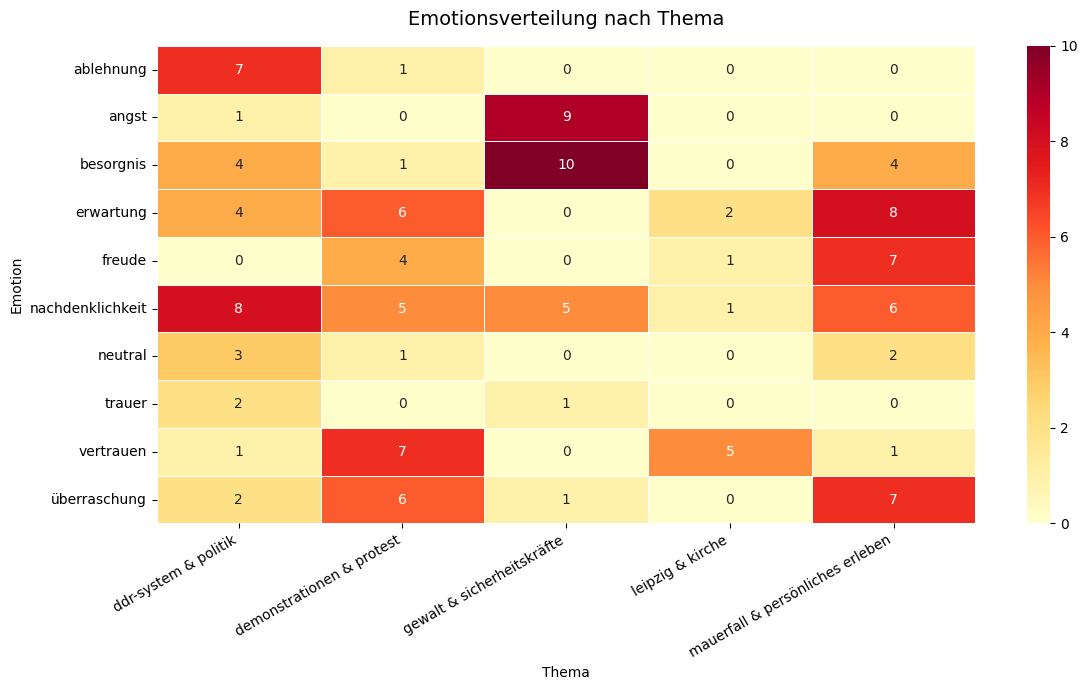

Saved: emotion_thema_heatmap.png


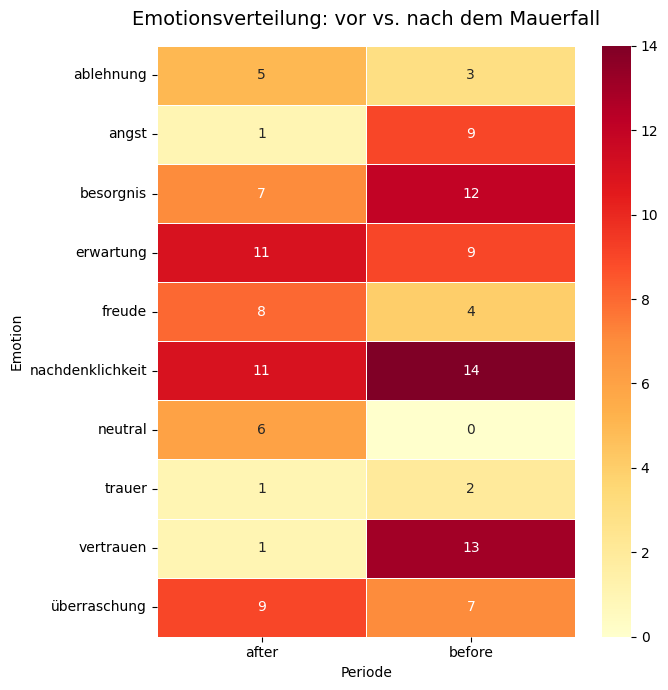

Saved: emotion_periode_heatmap.png


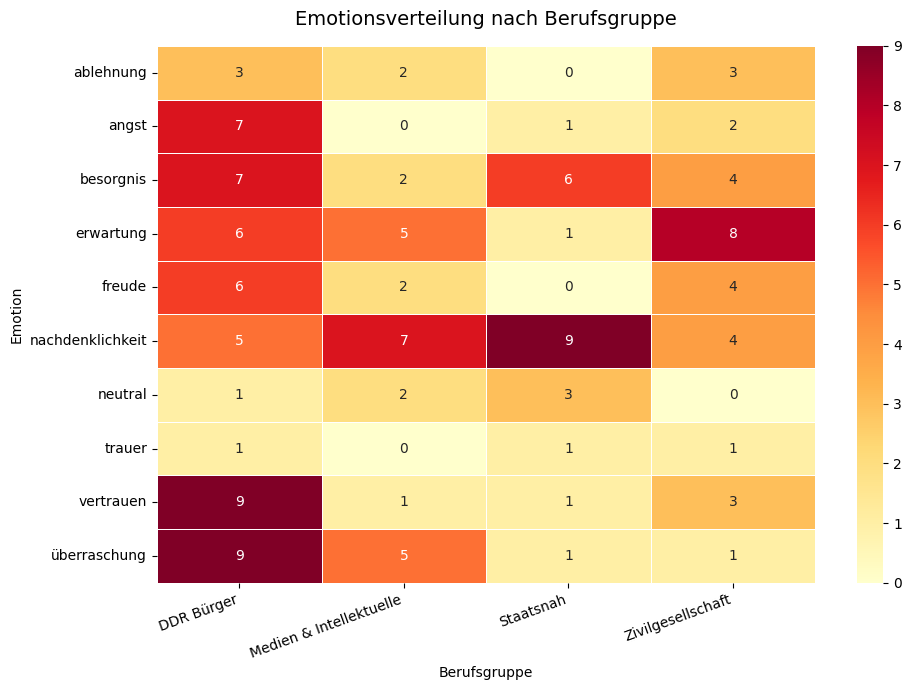

Saved: emotion_occupation_heatmap.png


In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("output/figures", exist_ok=True)

pivot_et = emotion_df.pivot_table(
    index='value', columns='thema', aggfunc='size', fill_value=0
)

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_et, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white')
plt.title('Emotionsverteilung nach Thema', fontsize=14, pad=15)
plt.xlabel('Thema')
plt.ylabel('Emotion')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("output/figures/emotion_thema_heatmap.png", dpi=150)
plt.show()
print("Saved: emotion_thema_heatmap.png")

pivot_ep = emotion_df.pivot_table(
    index='value', columns='period', aggfunc='size', fill_value=0
)

plt.figure(figsize=(7, 7))
sns.heatmap(pivot_ep, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white')
plt.title('Emotionsverteilung: vor vs. nach dem Mauerfall', fontsize=14, pad=15)
plt.xlabel('Periode')
plt.ylabel('Emotion')
plt.tight_layout()
plt.savefig("output/figures/emotion_periode_heatmap.png", dpi=150)
plt.show()
print("Saved: emotion_periode_heatmap.png")

pivot_eo = emotion_df.pivot_table(
    index='value', columns='occupation', aggfunc='size', fill_value=0
)

plt.figure(figsize=(10, 7))
sns.heatmap(pivot_eo, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white')
plt.title('Emotionsverteilung nach Berufsgruppe', fontsize=14, pad=15)
plt.xlabel('Berufsgruppe')
plt.ylabel('Emotion')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig("output/figures/emotion_occupation_heatmap.png", dpi=150)
plt.show()
print("Saved: emotion_occupation_heatmap.png")

In [86]:
print(results_df.groupby('period')['sentence'].count())
print(results_df.groupby('occupation')['sentence'].count())
print(f"ELAN Annotationen gesamt: {len(emotion_df)}")
print(f"davon Emotion-Segmente: {len(emotion_df)}")
print(f"davon Thema-Segmente: {len(thema_df)}")

period
after     321
before    384
Name: sentence, dtype: int64
occupation
DDR Bürger                 320
Medien & Intellektuelle    150
Staatsnah                   77
Zivilgesellschaft          158
Name: sentence, dtype: int64
ELAN Annotationen gesamt: 133
davon Emotion-Segmente: 133
davon Thema-Segmente: 133
